In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('vpd.csv', index_col = 'DATEPRD')

In [3]:
df.columns

Index(['NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'ON_STREAM_HRS',
       'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING',
       'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P',
       'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL',
       'BORE_WAT_VOL', 'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE'],
      dtype='object')

In [4]:
columns = ['well_code','well_name','on_stream_hrs','avg_dh_press','avg_dh_temp','avg_dp_tubing','avg_annulus_press','avg_choke_per','avg_choke_uom', \
           'avg_wellhead_press','avg_wellhead_temp','dp_choke_size','oil_vol_prod','gas_vol_prod','wat_vol_prod','wat_vol_inj','flow_kind','well_type']

In [5]:
df.columns = columns

In oil production the aim is to produce very large amounts of oil while conserving the reservoir drive(pressure) to enable production for a long period reaping a high ultimate recovery.
Various factors affect the volume of oil produced, factors which include the reservoirr pressure, the flow rate, the bottom hole pressure these are affect the ability to produce oil efficiently and sufficiently over a long period of time.


### CONSIDERATIONS

These factors would be divided into two Surface and subsurface, in order to understand how the affect oil production
#### Surface Conditions
1 choke valve opening
2 well head pressure

#### Subsurface Conditions
1 Reservoir pressure
2 Bottomhole pressure
3 Tubing pressure
4 Downhole pressure

The aim of these analysis would be to classify wells as either high, medium and low production wells and to provide advice on which wells need to be shut
in order ro conserve the reservoir pressure and increase productivity

In [6]:
df['well_code'].unique()

array([7405, 7078, 5599, 5351, 7289, 5693, 5769])

In [7]:
df['well_type'].unique()

array(['WI', 'OP'], dtype=object)

In [8]:
df['flow_kind'].unique()

array(['production', 'injection'], dtype=object)

In [9]:
df['well_name'].unique()

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D',
       '15/9-F-4', '15/9-F-5'], dtype=object)

In [10]:
df.groupby('well_type')['well_name'].nunique()

well_type
OP    6
WI    3
Name: well_name, dtype: int64

There are 7 wells present on the field, with well code ([7405, 7078, 5599, 5351, 7289, 5693, 5769])
one of the wells(5769) was initially used as an oil production well and was later converted to an injection well
On this field we have 2 injection wells and 5 oil wells presently

In [11]:
df0 = df[df['flow_kind'] == 'injection'] ## this code was used to distinguish the injection wells from production wells 

In [12]:
df0['well_name'].unique()

array(['15/9-F-4', '15/9-F-5'], dtype=object)

In [13]:
df0['well_code'].unique()

array([5693, 5769])

In [14]:
df_prd =df[df['flow_kind']== 'production']
## to get a subset of just the production wells

In [15]:
df_prd

,well_code,well_name,on_stream_hrs,avg_dh_press,avg_dh_temp,avg_dp_tubing,avg_annulus_press,avg_choke_per,avg_choke_uom,avg_wellhead_press,avg_wellhead_temp,dp_choke_size,oil_vol_prod,gas_vol_prod,wat_vol_prod,wat_vol_inj,flow_kind,well_type
DATEPRD,,,,,,,,,,,,,,,,,,
07-Apr-14,7405,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,%,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production,WI
08-Apr-14,7405,15/9-F-1 C,0.0,NaN,NaN,NaN,0.000,1.00306,%,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production,OP
09-Apr-14,7405,15/9-F-1 C,0.0,NaN,NaN,NaN,0.000,0.97901,%,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production,OP
10-Apr-14,7405,15/9-F-1 C,0.0,NaN,NaN,NaN,0.000,0.54576,%,0.000,0.000,0.000,0.0,0.0,0.0,NaN,production,OP
11-Apr-14,7405,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,%,33.098,10.480,33.072,0.0,0.0,0.0,NaN,production,OP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13-Sep-16,5769,15/9-F-5,0.0,NaN,NaN,NaN,0.285,0.67372,%,0.085,0.229,0.037,0.0,0.0,0.0,NaN,production,OP
14-Sep-16,5769,15/9-F-5,0.0,NaN,NaN,NaN,0.273,0.63609,%,0.078,0.229,0.019,0.0,0.0,0.0,NaN,production,OP
15-Sep-16,5769,15/9-F-5,0.0,NaN,NaN,NaN,0.287,0.67079,%,0.085,0.229,0.006,0.0,0.0,0.0,NaN,production,OP


In [16]:
df.index = pd.to_datetime(df.index)

C:\Users\Derah\AppData\Local\Temp\ipykernel_4532\3150677299.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


In [17]:
df.index.max() - df.index.min()

Timedelta('3379 days 00:00:00')

In [18]:
df_prd.groupby('well_name')['oil_vol_prod'].sum().sort_values(ascending = False)

well_name
15/9-F-12      4579620.0
15/9-F-14      3942270.0
15/9-F-11      1147860.0
15/9-F-1 C      177707.0
15/9-F-15 D     148520.0
15/9-F-5         41163.0
Name: oil_vol_prod, dtype: float64

In [19]:
df_prd.loc[(df_prd['on_stream_hrs'] == 0) & (df_prd['oil_vol_prod'] > 0)]

,well_code,well_name,on_stream_hrs,avg_dh_press,avg_dh_temp,avg_dp_tubing,avg_annulus_press,avg_choke_per,avg_choke_uom,avg_wellhead_press,avg_wellhead_temp,dp_choke_size,oil_vol_prod,gas_vol_prod,wat_vol_prod,wat_vol_inj,flow_kind,well_type
DATEPRD,,,,,,,,,,,,,,,,,,
17-Jan-15,7078,15/9-F-11,0.0,219.8,106.2,169.4,23.1,12.0,%,50.4,64.8,21.0,1027.0,150774.0,461.0,NaN,production,OP


In [20]:
df[df['well_name'] == '15/9-F-11']['on_stream_hrs'].mean().round(2)

np.float64(22.32)

In [21]:
df_prd.loc[(df_prd['on_stream_hrs'] == 0) & (df_prd['oil_vol_prod'] > 0),'on_stream_hrs'] = \
df[df['well_name'] == '15/9-F-11']['on_stream_hrs'].mean().round(2)

In [22]:
df_prd.loc[(df_prd['on_stream_hrs'] == 0) & (df_prd['oil_vol_prod'] > 0)]

,well_code,well_name,on_stream_hrs,avg_dh_press,avg_dh_temp,avg_dp_tubing,avg_annulus_press,avg_choke_per,avg_choke_uom,avg_wellhead_press,avg_wellhead_temp,dp_choke_size,oil_vol_prod,gas_vol_prod,wat_vol_prod,wat_vol_inj,flow_kind,well_type
DATEPRD,,,,,,,,,,,,,,,,,,


In [23]:
df_prd.groupby('well_name')[['oil_vol_prod','on_stream_hrs','wat_vol_prod','gas_vol_prod']].sum()

,oil_vol_prod,on_stream_hrs,wat_vol_prod,gas_vol_prod
well_name,,,,
15/9-F-1 C,177707.0,9983.58,207305.0,26440916.0
15/9-F-11,1147860.0,26028.55,1090818.0,174310528.0
15/9-F-12,4579620.0,65204.31,6833353.0,667542296.0
15/9-F-14,3942270.0,62773.89,7121231.0,578009540.0
15/9-F-15 D,148520.0,17824.95,52350.0,22505357.0
15/9-F-5,41163.0,2973.33,13536.0,6561830.0


In [24]:
df_prdwells = df_prd.groupby('well_name')[['oil_vol_prod','on_stream_hrs','wat_vol_prod','gas_vol_prod']].sum()

In [25]:
df_prdwells['prd_eff'] = df_prdwells['oil_vol_prod']/df_prdwells['on_stream_hrs']

In [26]:
df_prdwells.sort_values(by=['oil_vol_prod'], ascending = False)

,oil_vol_prod,on_stream_hrs,wat_vol_prod,gas_vol_prod,prd_eff
well_name,,,,,
15/9-F-12,4579620.0,65204.31,6833353.0,667542296.0,70.234928
15/9-F-14,3942270.0,62773.89,7121231.0,578009540.0,62.801110
15/9-F-11,1147860.0,26028.55,1090818.0,174310528.0,44.100036
15/9-F-1 C,177707.0,9983.58,207305.0,26440916.0,17.799927
15/9-F-15 D,148520.0,17824.95,52350.0,22505357.0,8.332141
15/9-F-5,41163.0,2973.33,13536.0,6561830.0,13.844074


In [27]:
df_prdwells['water_cut'] = df_prdwells['wat_vol_prod']/(df_prdwells['oil_vol_prod'] + df_prdwells['wat_vol_prod'])

In [28]:
df_prdwells.sort_values(by = ['oil_vol_prod','prd_eff','water_cut'], ascending = [False,False,False])

,oil_vol_prod,on_stream_hrs,wat_vol_prod,gas_vol_prod,prd_eff,water_cut
well_name,,,,,,
15/9-F-12,4579620.0,65204.31,6833353.0,667542296.0,70.234928,0.598736
15/9-F-14,3942270.0,62773.89,7121231.0,578009540.0,62.801110,0.643669
15/9-F-11,1147860.0,26028.55,1090818.0,174310528.0,44.100036,0.487260
15/9-F-1 C,177707.0,9983.58,207305.0,26440916.0,17.799927,0.538438
15/9-F-15 D,148520.0,17824.95,52350.0,22505357.0,8.332141,0.260616
15/9-F-5,41163.0,2973.33,13536.0,6561830.0,13.844074,0.247463


In [29]:
df_prdwells['prod_gor'] = df_prdwells['gas_vol_prod']/df_prdwells['oil_vol_prod']

In [30]:
df_prdwells.sort_values(by = ['prd_eff','water_cut','prod_gor'], ascending = [False,False,False])

,oil_vol_prod,on_stream_hrs,wat_vol_prod,gas_vol_prod,prd_eff,water_cut,prod_gor
well_name,,,,,,,
15/9-F-12,4579620.0,65204.31,6833353.0,667542296.0,70.234928,0.598736,145.763687
15/9-F-14,3942270.0,62773.89,7121231.0,578009540.0,62.801110,0.643669,146.618456
15/9-F-11,1147860.0,26028.55,1090818.0,174310528.0,44.100036,0.487260,151.856958
15/9-F-1 C,177707.0,9983.58,207305.0,26440916.0,17.799927,0.538438,148.789389
15/9-F-5,41163.0,2973.33,13536.0,6561830.0,13.844074,0.247463,159.410879
15/9-F-15 D,148520.0,17824.95,52350.0,22505357.0,8.332141,0.260616,151.530817


In [31]:
## From my analysis i commend the engineers on site for making a good decision switching well F-5 to a injection well
## I would also recommend that attentionbe switched to well 1C and 15D, from the analysis it can be seen that 1C produces
## more relative to 15D for a lower cumulative on stream hours, the

In [32]:
df_prdwells['on_stream_day'] = df_prdwells['on_stream_hrs']/24

In [33]:
df_prdwells['oil(bbl/day)'] = df_prdwells['oil_vol_prod']/df_prdwells['on_stream_day']

In [34]:
df_prdwells['gas(mmscf/day)'] =( df_prdwells['gas_vol_prod']/(df_prdwells['on_stream_day'] * 1000000))

In [35]:
df_prd_f_data = df_prdwells.sort_values(by = ['oil(bbl/day)','gas(mmscf/day)'], ascending = [False,False])

## Decline rate Analysis

In [36]:
df_prdd =df.loc[(df['flow_kind']== 'production') & (df['oil_vol_prod'] > 0)]

In [37]:
df_prd.groupby('well_name')['well_code'].count().sort_values(ascending = False)

well_name
15/9-F-12      3056
15/9-F-14      3056
15/9-F-11      1165
15/9-F-15 D     978
15/9-F-1 C      746
15/9-F-5        160
Name: well_code, dtype: int64

In [38]:
## FOR WELL 12
data12 = df_prdd.loc[df_prdd['well_name'] == '15/9-F-12']

drange = data12['well_code'].count()
if drange > 1000:
    early_prd = data12['oil_vol_prod'].iloc[:100].sum().round(2)
    late_prd = data12['oil_vol_prod'].iloc[drange-100 : drange + 1].sum().round(2)
decline_rate12 = (early_prd - late_prd)/(early_prd)
print(decline_rate12)

0.9448235163943496


In [39]:
## FOR WELL 14
data14 = df_prdd.loc[df_prdd['well_name'] == '15/9-F-14']
drange1 = data14['well_code'].count()
ratio = 100/drange
rratio = ratio.round(4)
r = drange1 * rratio
r = round(r)
early_prd14 = data14['oil_vol_prod'].iloc[:r].sum().round(2)
late_prd14 = data14['oil_vol_prod'].iloc[drange1 - r : drange1 +1].sum().round(2)
decline_rate14 = (early_prd14 -late_prd14)/(early_prd14)
print(decline_rate14)

0.972482356040543


In [40]:
## FOR WELL 11
data11 = df_prdd.loc[df_prdd['well_name'] == '15/9-F-11']
drange2 = data11['well_code'].count()
ratio = 100/drange
rratio = ratio.round(4)
t = drange2 * rratio
t = round(t)
early_prd11 = data11['oil_vol_prod'].iloc[:t].sum().round(2)
late_prd11 = data11['oil_vol_prod'].iloc[drange2 - t : drange2 +1].sum().round(2)
decline_rate11 = (early_prd11 -late_prd11)/(early_prd11)
print(decline_rate11)

0.4501075208758064


In [41]:
## FOR WELL 15
data15 = df_prdd.loc[df_prdd['well_name'] == '15/9-F-15 D']
drange3 = data15['well_code'].count()
ratio = 100/drange
rratio = ratio.round(4)
u = drange3 * rratio
u = round(u)
early_prd15 = data15['oil_vol_prod'].iloc[:u].sum().round(2)
late_prd15 = data15['oil_vol_prod'].iloc[drange3 - t : drange3 +1].sum().round(2)
decline_rate15 = (early_prd15 -late_prd15)/(early_prd15)
print(decline_rate15)

0.4484955405272959


In [42]:
## FOR WELL 1C
data1 = df_prdd.loc[df_prdd['well_name'] == '15/9-F-1 C']
drange4 = data1['well_code'].count()
ratio = 100/drange
rratio = ratio.round(4)
v = drange4 * rratio
v = round(v)
early_prd1 = data1['oil_vol_prod'].iloc[:v].sum().round(2)
late_prd1 = data1['oil_vol_prod'].iloc[drange4 - v : drange4 +1].sum().round(2)
decline_rate1 = (early_prd1 -late_prd1)/(early_prd1)
print(decline_rate1)

0.7668027367331686


In [43]:
## FOR WELL 5
data5 = df_prdd.loc[df_prdd['well_name'] == '15/9-F-5']
drange5 = data5['well_code'].count()
ratio = 100/drange
rratio = ratio.round(4)
w = drange5 * rratio
w = round(w)
early_prd5 = data5['oil_vol_prod'].iloc[:w].sum().round(2)
late_prd5 = data5['oil_vol_prod'].iloc[drange5 - w : drange5 +1].sum().round(2)
decline_rate5 = (early_prd5 -late_prd5)/(early_prd5)
print(decline_rate5)

-0.29034531360112753


In [44]:
df_prd_f_data

,oil_vol_prod,on_stream_hrs,wat_vol_prod,gas_vol_prod,prd_eff,water_cut,prod_gor,on_stream_day,oil(bbl/day),gas(mmscf/day)
well_name,,,,,,,,,,
15/9-F-12,4579620.0,65204.31,6833353.0,667542296.0,70.234928,0.598736,145.763687,2716.846250,1685.638265,0.245705
15/9-F-14,3942270.0,62773.89,7121231.0,578009540.0,62.801110,0.643669,146.618456,2615.578750,1507.226651,0.220987
15/9-F-11,1147860.0,26028.55,1090818.0,174310528.0,44.100036,0.487260,151.856958,1084.522917,1058.400871,0.160726
15/9-F-1 C,177707.0,9983.58,207305.0,26440916.0,17.799927,0.538438,148.789389,415.982500,427.198260,0.063563
15/9-F-5,41163.0,2973.33,13536.0,6561830.0,13.844074,0.247463,159.410879,123.888750,332.257772,0.052966
15/9-F-15 D,148520.0,17824.95,52350.0,22505357.0,8.332141,0.260616,151.530817,742.706250,199.971388,0.030302


In [45]:
declinerate_data = [decline_rate12,decline_rate14,decline_rate11,decline_rate1,decline_rate5,decline_rate15]

In [46]:
df_prd_f_data['decline_rate'] = declinerate_data

In [47]:
df_prd_f_data


,oil_vol_prod,on_stream_hrs,wat_vol_prod,gas_vol_prod,prd_eff,water_cut,prod_gor,on_stream_day,oil(bbl/day),gas(mmscf/day),decline_rate
well_name,,,,,,,,,,,
15/9-F-12,4579620.0,65204.31,6833353.0,667542296.0,70.234928,0.598736,145.763687,2716.846250,1685.638265,0.245705,0.944824
15/9-F-14,3942270.0,62773.89,7121231.0,578009540.0,62.801110,0.643669,146.618456,2615.578750,1507.226651,0.220987,0.972482
15/9-F-11,1147860.0,26028.55,1090818.0,174310528.0,44.100036,0.487260,151.856958,1084.522917,1058.400871,0.160726,0.450108
15/9-F-1 C,177707.0,9983.58,207305.0,26440916.0,17.799927,0.538438,148.789389,415.982500,427.198260,0.063563,0.766803
15/9-F-5,41163.0,2973.33,13536.0,6561830.0,13.844074,0.247463,159.410879,123.888750,332.257772,0.052966,-0.290345
15/9-F-15 D,148520.0,17824.95,52350.0,22505357.0,8.332141,0.260616,151.530817,742.706250,199.971388,0.030302,0.448496


In [48]:
df_final = df_prd_f_data[['oil_vol_prod','gas_vol_prod','wat_vol_prod','on_stream_hrs','prd_eff','water_cut','decline_rate']]

In [49]:
df_final

,oil_vol_prod,gas_vol_prod,wat_vol_prod,on_stream_hrs,prd_eff,water_cut,decline_rate
well_name,,,,,,,
15/9-F-12,4579620.0,667542296.0,6833353.0,65204.31,70.234928,0.598736,0.944824
15/9-F-14,3942270.0,578009540.0,7121231.0,62773.89,62.801110,0.643669,0.972482
15/9-F-11,1147860.0,174310528.0,1090818.0,26028.55,44.100036,0.487260,0.450108
15/9-F-1 C,177707.0,26440916.0,207305.0,9983.58,17.799927,0.538438,0.766803
15/9-F-5,41163.0,6561830.0,13536.0,2973.33,13.844074,0.247463,-0.290345
15/9-F-15 D,148520.0,22505357.0,52350.0,17824.95,8.332141,0.260616,0.448496


## Normalizing our metric data in order to accurately rank the wells 

In [50]:
df_final['norm_oil'] = (df_final['oil_vol_prod'] - df_final['oil_vol_prod'].min())/(df_final['oil_vol_prod'].max() -df_final['oil_vol_prod'].min())
df_final['norm_prdeff'] = (df_final['prd_eff'] - df_final['prd_eff'].min())/(df_final['prd_eff'].max() -df_final['prd_eff'].min())
df_final['norm_wcut'] = 1 - ((df_final['water_cut'] - df_final['water_cut'].min())/(df_final['water_cut'].max() -df_final['water_cut'].min()))
df_final['norm_drate'] = 1 - ((df_final['decline_rate'] - df_final['decline_rate'].min())/(df_final['decline_rate'].max() -df_final['decline_rate'].min()))

C:\Users\Derah\AppData\Local\Temp\ipykernel_4532\2539948916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['norm_oil'] = (df_final['oil_vol_prod'] - df_final['oil_vol_prod'].min())/(df_final['oil_vol_prod'].max() -df_final['oil_vol_prod'].min())
C:\Users\Derah\AppData\Local\Temp\ipykernel_4532\2539948916.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['norm_prdeff'] = (df_final['prd_eff'] - df_final['prd_eff'].min())/(df_final['prd_eff'].max() -df_final['prd_eff'].min())
C:\Users\

In [51]:
df_final

,oil_vol_prod,gas_vol_prod,wat_vol_prod,on_stream_hrs,prd_eff,water_cut,decline_rate,norm_oil,norm_prdeff,norm_wcut,norm_drate
well_name,,,,,,,,,,,
15/9-F-12,4579620.0,667542296.0,6833353.0,65204.31,70.234928,0.598736,0.944824,1.000000,1.000000,0.113409,0.021902
15/9-F-14,3942270.0,578009540.0,7121231.0,62773.89,62.801110,0.643669,0.972482,0.859567,0.879911,0.000000,0.000000
15/9-F-11,1147860.0,174310528.0,1090818.0,26028.55,44.100036,0.487260,0.450108,0.243849,0.577808,0.394767,0.413655
15/9-F-1 C,177707.0,26440916.0,207305.0,9983.58,17.799927,0.538438,0.766803,0.030086,0.152946,0.265597,0.162872
15/9-F-5,41163.0,6561830.0,13536.0,2973.33,13.844074,0.247463,-0.290345,0.000000,0.089042,1.000000,1.000000
15/9-F-15 D,148520.0,22505357.0,52350.0,17824.95,8.332141,0.260616,0.448496,0.023655,0.000000,0.966803,0.414931


In order to get the composite score of the normalized data, each metric would be asigned a weighted average based on how important each metric is

production efficiency is given 35%
cumulative oil is given 30%
water cut is given 20%
decline rate is given 15%

In [52]:
df_final['comp_score'] = (df_final['norm_oil']*0.30) + (df_final['norm_prdeff'] * 0.35) + (df_final['norm_wcut'] * 0.20) + (df_final['norm_drate'] * 0.15)

In [53]:
df_final.sort_values(by = 'comp_score', ascending = False)

,oil_vol_prod,gas_vol_prod,wat_vol_prod,on_stream_hrs,prd_eff,water_cut,decline_rate,norm_oil,norm_prdeff,norm_wcut,norm_drate,comp_score
well_name,,,,,,,,,,,,
15/9-F-12,4579620.0,667542296.0,6833353.0,65204.31,70.234928,0.598736,0.944824,1.000000,1.000000,0.113409,0.021902,0.675967
15/9-F-14,3942270.0,578009540.0,7121231.0,62773.89,62.801110,0.643669,0.972482,0.859567,0.879911,0.000000,0.000000,0.565839
15/9-F-11,1147860.0,174310528.0,1090818.0,26028.55,44.100036,0.487260,0.450108,0.243849,0.577808,0.394767,0.413655,0.416389
15/9-F-5,41163.0,6561830.0,13536.0,2973.33,13.844074,0.247463,-0.290345,0.000000,0.089042,1.000000,1.000000,0.381165
15/9-F-15 D,148520.0,22505357.0,52350.0,17824.95,8.332141,0.260616,0.448496,0.023655,0.000000,0.966803,0.414931,0.262697
15/9-F-1 C,177707.0,26440916.0,207305.0,9983.58,17.799927,0.538438,0.766803,0.030086,0.152946,0.265597,0.162872,0.140107


In [54]:
df_final['class'] = np.select([df_final['comp_score'] > 0.60, df_final['comp_score'] < 0.30], ['High','Low'], default = 'Medium')

In [55]:
df_final = df_final.sort_values(by = 'comp_score', ascending = False)

In [56]:
df_final

,oil_vol_prod,gas_vol_prod,wat_vol_prod,on_stream_hrs,prd_eff,water_cut,decline_rate,norm_oil,norm_prdeff,norm_wcut,norm_drate,comp_score,class
well_name,,,,,,,,,,,,,
15/9-F-12,4579620.0,667542296.0,6833353.0,65204.31,70.234928,0.598736,0.944824,1.000000,1.000000,0.113409,0.021902,0.675967,High
15/9-F-14,3942270.0,578009540.0,7121231.0,62773.89,62.801110,0.643669,0.972482,0.859567,0.879911,0.000000,0.000000,0.565839,Medium
15/9-F-11,1147860.0,174310528.0,1090818.0,26028.55,44.100036,0.487260,0.450108,0.243849,0.577808,0.394767,0.413655,0.416389,Medium
15/9-F-5,41163.0,6561830.0,13536.0,2973.33,13.844074,0.247463,-0.290345,0.000000,0.089042,1.000000,1.000000,0.381165,Medium
15/9-F-15 D,148520.0,22505357.0,52350.0,17824.95,8.332141,0.260616,0.448496,0.023655,0.000000,0.966803,0.414931,0.262697,Low
15/9-F-1 C,177707.0,26440916.0,207305.0,9983.58,17.799927,0.538438,0.766803,0.030086,0.152946,0.265597,0.162872,0.140107,Low


## VISUALIZATION OF DATA

In [67]:
sns.set_theme( style = 'darkgrid')

In [69]:
my_colour = {'High' : 'green', 'Medium' : 'blue', 'Low' :'red'}

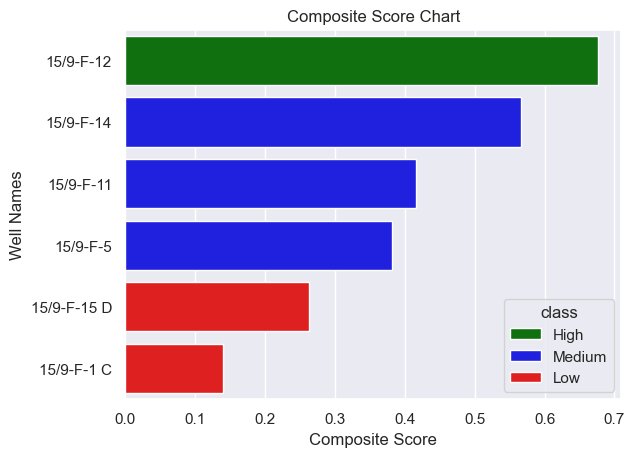

In [70]:
sns.barplot( data = df_final, x = 'comp_score', y = df_final.index, hue = 'class', palette = my_colour)

plt.title('Composite Score Chart')
plt.xlabel('Composite Score')
plt.ylabel('Well Names')
plt.show()

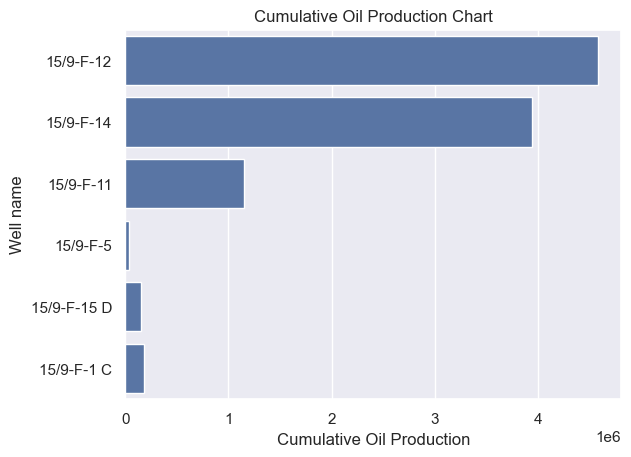

In [71]:
sns.barplot( data = df_final, x = 'oil_vol_prod', y = df_final.index)
plt.title('Cumulative Oil Production Chart')
plt.xlabel('Cumulative Oil Production')
plt.ylabel('Well name')
plt.show()

In [61]:
df23 = df_final.reset_index()

In [62]:
df23 = pd.melt(df23, id_vars = 'well_name', value_vars = ['norm_oil','norm_prdeff','norm_wcut','norm_drate'], var_name = 'metric', value_name = 'metric value')

<Axes: xlabel='well_name', ylabel='metric value'>

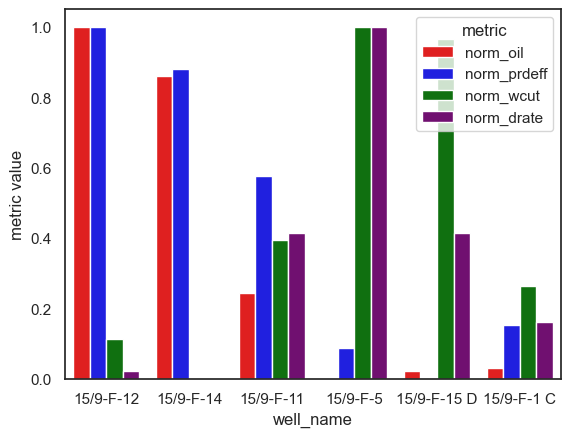

In [63]:
my_colors = {'norm_oil':'red','norm_prdeff':'blue','norm_wcut':'green','norm_drate':'purple'}
sns.barplot( data = df23, x = 'well_name', y = 'metric value', hue = 'metric', palette = my_colors)